In [1]:
import sys
import os
import seaborn as sns

import numpy as np
import torchvision 
import argparse
import json

from src.utils.io import to_json
from src.metrics import compute_scores, sample_N, sample_balanced
from src.utils.data_transforms import ToTensor, OneHot, Scale, HUScale
from src.datasets import *


target_size = 256
dataset = 'wbc/cv'
n_classes = 2
transforms_list = []
grayscale = True

transforms_list.append(OneHot(n_classes=n_classes))
transforms = torchvision.transforms.Compose(transforms_list) if transforms_list else None


d_reference = Seg2D_Dataset(split='Train', dataset=dataset, transform=transforms, grayscale=grayscale, target_size=target_size)
d_eval = Seg2D_Dataset(split='Test', dataset=dataset, transform=transforms, grayscale=grayscale, target_size=target_size)
d_eval_np = Seg2D_Dataset(split='Test', dataset=dataset, grayscale=grayscale, target_size=target_size)

In [4]:
from torch.utils.data import Subset

scores = compute_scores(d_eval_np, n_classes)
idxs = sample_balanced(scores, n_buckets=5, min_val=0)
d_eval_np_sub = Subset(d_eval_np, idxs)
scores_sub = compute_scores(d_eval_np_sub, n_classes)

len(d_eval_np_sub)

370

<Axes: ylabel='Count'>

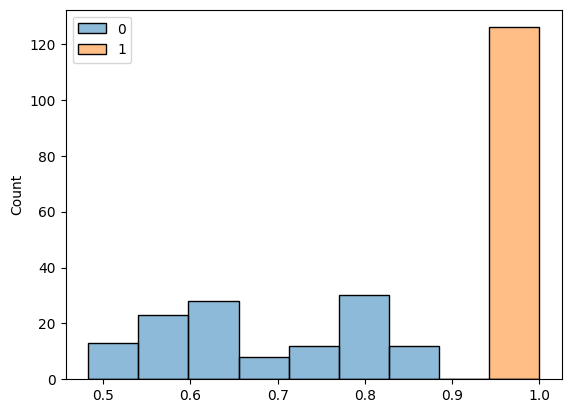

In [51]:
sns.histplot(scores_sub)

In [6]:
from src.utils.io import read_json
import numpy as np

data_useg = read_json('test_useg.json')
data_sam = read_json('test_sam.json')

def process_dataset(data):
    real_scores = []
    rca_scores = []
    for x in data:
        rca_dice_list = x['RCA score']['Dice']

        for rca_array in rca_dice_list:
            rca_array = np.array(rca_array)
            if rca_array.ndim == 1:
                rca_array = rca_array.reshape(-1, 1)

        real_scores.append(x['Real score']['Dice'])
        rca_scores.append(np.array([v for v in rca_dice_list]))

    return {'Real score': real_scores, 'RCA score': rca_scores}

res_useg = process_dataset(data_useg)
res_sam = process_dataset(data_sam)

In [7]:
from scipy.stats import pearsonr
import pandas as pd

results = {}
dataset = 'hc18'

real = np.array(res_useg['Real score'])
rca = np.array(res_useg['RCA score']).max(axis=1)

# Ensure 2D shape for consistency (samples, classes)
if real.ndim == 1:
    real = real.reshape(-1, 1)
if rca.ndim == 1:
    rca = rca.reshape(-1, 1)

abs_error = np.abs(real - rca)
mae = np.mean(abs_error, axis=0)

# Per-class correlation
correlations = []
for i in range(real.shape[1]):
    corr, _ = pearsonr(real[:, i], rca[:, i])
    correlations.append(corr)

# Store results as tuples (MAE, Correlation) per class
results[dataset.upper()] = {
    f'Class {i} MAE': mae[i] for i in range(len(mae))
} | {
    f'Class {i} Corr': correlations[i] for i in range(len(correlations))
}

df = pd.DataFrame.from_dict(results, orient='index')
df

,Class 0 MAE,Class 0 Corr
HC18,0.157718,0.685668


<Axes: >

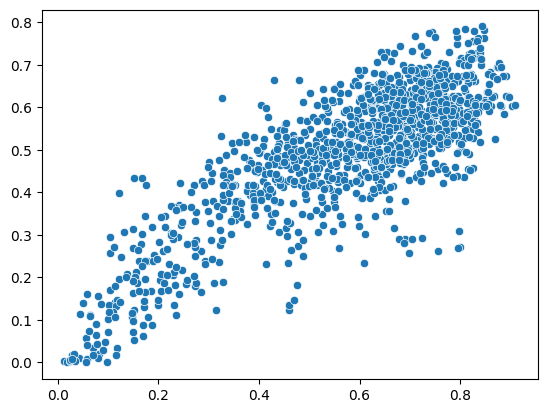

In [4]:
import seaborn as sns

#sns.scatterplot(x=real.squeeze(), y=rca.squeeze())
sns.scatterplot(x=real[:, 0], y=rca[:, 0])

In [10]:
import os

datasets = ['ISIC 2018','SCD','WBC/CV','WBC/JTSC','3D-IRCADB/LIVER','NUCLS','HC18','PH2','PSFHS']
for dataset in datasets:
    path = f'datasets/{dataset}/Test'
    